# 1D Quantum Harmonic Oscillator: Grid-Spacing Convergence and Solver Cost

This notebook covers two of the items requested in the checkpoint feedback:

- how the energy error behaves as the grid is refined at **fixed box size**, and
- how matrix size, solver settings, and runtime scale with the number of grid points.

The **box-size** study is deliberately not included here. That test holds the grid
spacing fixed and moves the boundaries instead, and it is being handled separately;
mixing the two sweeps in one loop is exactly what makes the two error sources
impossible to separate.

All conventions match `qho_1d_hamiltonian.ipynb`: dimensionless units
$\hbar = m = \omega = 1$, the interval $x \in [-L, L]$, Dirichlet boundary conditions
$\psi(\pm L) = 0$, a centered second-order finite difference, sparse CSR storage, and
the lowest 6 states. The analytic energies are $E_n = n + \tfrac{1}{2}$.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh
from scipy.linalg import eigh_tridiagonal
pd.set_option("display.precision", 10)

## Shared construction

Both studies call the same two helpers, so every row below comes from an identical
discretization. Only $N$ changes in this notebook; $L$ is held at 8 throughout.

In [2]:
hbar = 1.0
mass = 1.0
omega = 1.0
L = 8.0
num_states = 6
n = np.arange(num_states)
energies_exact = n + 0.5


def build_hamiltonian(L, N):
    x_full = np.linspace(-L, L, N)
    dx = x_full[1] - x_full[0]
    x = x_full[1:-1]
    M = x.size
    D2 = diags(
        diagonals=[np.ones(M - 1), -2.0 * np.ones(M), np.ones(M - 1)],
        offsets=[-1, 0, 1],
        shape=(M, M),
        format="csr",
    ) / dx**2
    V = 0.5 * mass * omega**2 * x**2
    H = -0.5 * (hbar**2 / mass) * D2 + diags(V, offsets=0, format="csr")
    return x, dx, M, H


def solve(L, N, num_states=num_states):
    x, dx, M, H = build_hamiltonian(L, N)
    energies, states = eigsh(H, k=num_states, which="SA")
    order = np.argsort(energies)
    energies = energies[order]
    states = states[:, order]
    for j in range(num_states):
        states[:, j] /= np.sqrt(np.trapezoid(np.abs(states[:, j])**2, x))
    return {"x": x, "dx": dx, "M": M, "nnz": H.nnz, "energies": energies, "states": states}

In [3]:
baseline = solve(L, 1000)
baseline_error = np.abs(baseline["energies"] - energies_exact)
print(f"dx at N = 1000: {baseline['dx']:.10f}")
print(f"E_0: {baseline['energies'][0]:.10f}")
print(f"E_5: {baseline['energies'][5]:.10f}")
assert np.allclose(baseline["energies"], [0.4999919838, 1.4999599187, 2.4998957872,
                                          3.4997995877, 4.4996713187, 5.4995109787], atol=1e-9)
print("Baseline reproduces the energies from qho_1d_hamiltonian.ipynb.")

dx at N = 1000: 0.0160160160
E_0: 0.4999919838
E_5: 5.4995109787
Baseline reproduces the energies from qho_1d_hamiltonian.ipynb.


## Grid-spacing study

The physical box is fixed at $x \in [-8, 8]$ and only the number of grid points is
increased, so $\Delta x = 2L/(N-1)$ shrinks while the boundaries stay put. Any change
in the energies is therefore a discretization effect and not a box effect.

In [4]:
N_values = [200, 400, 800, 1600, 3200, 6400]
rows = []
grid_errors = []
for N in N_values:
    result = solve(L, N)
    error = np.abs(result["energies"] - energies_exact)
    grid_errors.append(error)
    rows.append({"N": N, "M": result["M"], "dx": result["dx"],
                 **{f"|dE_{j}|": error[j] for j in range(num_states)}})
grid_errors = np.array(grid_errors)
dx_values = np.array([r["dx"] for r in rows])

grid_study = pd.DataFrame(rows)
grid_study

,N,M,dx,|dE_0|,|dE_1|,|dE_2|,|dE_3|,|dE_4|,|dE_5|
0,200,198,0.0804020101,0.0002020968,0.0010108116,0.0026290613,0.0050578333,0.0082981191,0.0123509142
1,400,398,0.0401002506,0.0000502560,0.0002513002,0.0006534391,0.0012567335,0.0020612442,0.0030670320
2,800,798,0.0200250313,0.0000125316,0.0000626594,0.0001629180,0.0003133113,0.0005138430,0.0007645170
3,1600,1598,0.0100062539,0.0000031289,0.0000156447,0.0000406765,0.0000782245,0.0001282890,0.0001908702
4,3200,3198,0.0050015630,0.0000007817,0.0000039087,0.0000101626,0.0000195436,0.0000320515,0.0000476865
5,6400,6398,0.0025003907,0.0000001954,0.0000009769,0.0000025399,0.0000048843,0.0000080103,0.0000119178


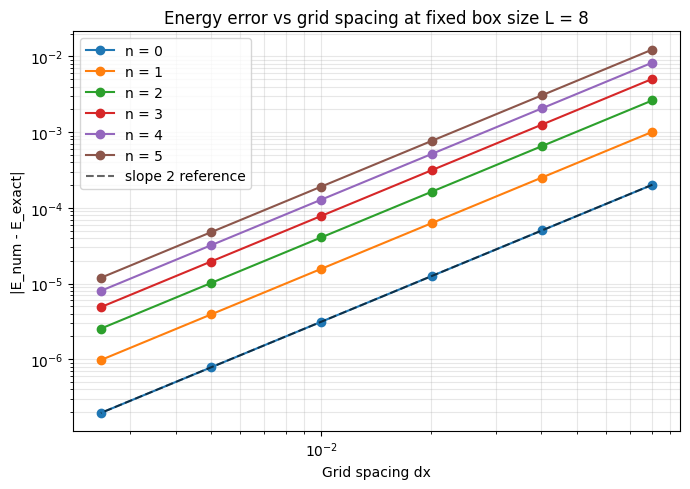

In [5]:
plt.figure(figsize=(7, 5))
for j in range(num_states):
    plt.loglog(dx_values, grid_errors[:, j], "o-", label=f"n = {j}")
plt.loglog(dx_values, grid_errors[0, 0] * (dx_values / dx_values[0])**2, "k--",
           alpha=0.6, label="slope 2 reference")
plt.xlabel("Grid spacing dx")
plt.ylabel("|E_num - E_exact|")
plt.title("Energy error vs grid spacing at fixed box size L = 8")
plt.grid(True, alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
slopes = [np.polyfit(np.log(dx_values), np.log(grid_errors[:, j]), 1)[0] for j in range(num_states)]
convergence_order = pd.DataFrame({
    "n": n,
    "Fitted slope": slopes,
    "Error at dx = 0.0804": grid_errors[0],
    "Error at dx = 0.0025": grid_errors[-1],
    "Reduction factor": grid_errors[0] / grid_errors[-1],
})
convergence_order

,n,Fitted slope,Error at dx = 0.0804,Error at dx = 0.0025,Reduction factor
0,0,2.0000966208,0.0002020968,0.0000001954,1034.4136635113
1,1,2.0001734039,0.0010108116,0.0000009769,1034.7474261892
2,2,2.0002594624,0.0026290613,0.0000025399,1035.1217107315
3,3,2.0003509545,0.0050578333,0.0000048843,1035.5196750280
4,4,2.0004445455,0.0082981191,0.0000080103,1035.9268921996
5,5,2.0005395728,0.0123509142,0.0000119178,1036.3407498609


## Leading-order error model

The fitted slopes confirm the expected $O(\Delta x^2)$ behaviour, so the error should
be $|\Delta E_n| = C_n \Delta x^2$ for some constant depending on the state. Dividing
the measured errors by $\Delta x^2$ gives values that settle on
$\tfrac{1}{32}, \tfrac{5}{32}, \tfrac{13}{32}, \tfrac{25}{32}, \tfrac{41}{32}, \tfrac{61}{32}$,
whose numerators are $2n^2 + 2n + 1$. That suggests

$$
\Delta E_n \simeq -\frac{\Delta x^2}{32}\left(2n^2 + 2n + 1\right),
$$

with the minus sign because the finite difference understates the curvature and so
understates the kinetic energy. The table below tests this prediction, which has no
fitted parameters, against the measured errors.

In [7]:
predicted = np.outer(dx_values**2, (2 * n**2 + 2 * n + 1) / 32.0)
model_check = pd.DataFrame({"N": N_values, "dx": dx_values})
for j in range(num_states):
    model_check[f"ratio n={j}"] = grid_errors[:, j] / predicted[:, j]
model_check

,N,dx,ratio n=0,ratio n=1,ratio n=2,ratio n=3,ratio n=4,ratio n=5
0,200,0.0804020101,1.0004045208,1.0007287277,1.0010909127,1.0014762817,1.0018713885,1.0022716285
1,400,0.0401002506,1.0001005306,1.0001809941,1.0002707757,1.0003661727,1.0004638377,1.0005626238
2,800,0.0200250313,1.0000250678,1.0000451170,1.0000674896,1.0000912498,1.0001155669,1.0001401535
3,1600,0.0100062539,1.0000061914,1.0000112896,1.0000168406,1.0000227778,1.0000288456,1.0000349827
4,3200,0.0050015630,1.0000009414,1.0000026186,1.0000042304,1.0000056997,1.0000072231,1.0000087194
5,6400,0.0025003907,0.9999987674,1.0000001839,1.0000003893,1.0000008767,1.0000021515,1.0000021392


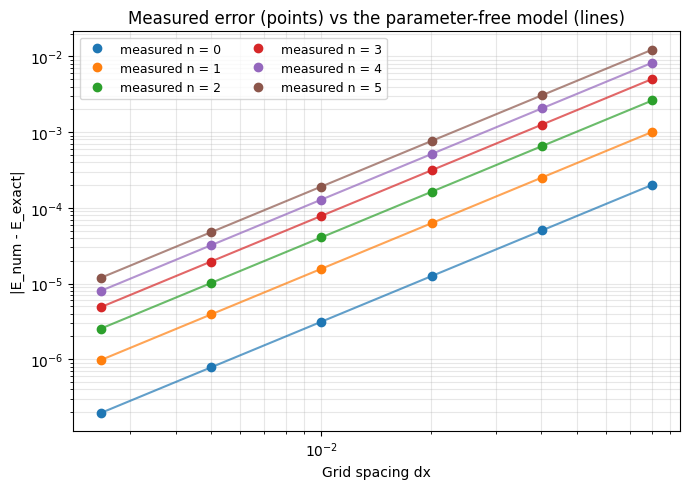

In [8]:
plt.figure(figsize=(7, 5))
for j in range(num_states):
    plt.loglog(dx_values, grid_errors[:, j], "o", label=f"measured n = {j}")
plt.gca().set_prop_cycle(None)
for j in range(num_states):
    plt.loglog(dx_values, predicted[:, j], "-", alpha=0.7)
plt.xlabel("Grid spacing dx")
plt.ylabel("|E_num - E_exact|")
plt.title("Measured error (points) vs the parameter-free model (lines)")
plt.grid(True, alpha=0.3, which="both")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

## Matrix size, solver settings, and runtime

The same Hamiltonians are now solved with four different configurations:

| Label | Call | Notes |
| --- | --- | --- |
| `eigsh SA` | `eigsh(H, k=6, which="SA")` | Lanczos on the sparse matrix, lowest algebraic eigenvalues |
| `eigsh shift-invert` | `eigsh(H, k=6, sigma=0.0, which="LM")` | Lanczos on $(H - \sigma I)^{-1}$, which clusters the wanted states at the top of the transformed spectrum |
| `eigh_tridiagonal` | `eigh_tridiagonal(d, e, select="i", select_range=(0, 5))` | direct LAPACK solver for the tridiagonal form |
| `dense eigh` | `np.linalg.eigh(H.toarray())` | full spectrum of the dense matrix, run only up to $M \approx 2000$ |

Each timing is the best of a few repeats. Memory columns compare the stored sparse
entries with the $M^2$ doubles a dense copy would require.

In [9]:
def best_time(call, repeats=3):
    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        call()
        times.append(time.perf_counter() - start)
    return min(times)


timing_rows = []
for N in N_values:
    x, dx, M, H = build_hamiltonian(L, N)
    H_csc = H.tocsc()
    diag_ref = hbar**2 / (mass * dx**2) + 0.5 * mass * omega**2 * x**2
    offdiag_ref = -0.5 * (hbar**2 / mass) * np.ones(M - 1) / dx**2
    repeats = 3 if M <= 3200 else 1
    t_sa = best_time(lambda: eigsh(H, k=num_states, which="SA"), repeats)
    t_si = best_time(lambda: eigsh(H_csc, k=num_states, sigma=0.0, which="LM"), 3)
    t_tri = best_time(lambda: eigh_tridiagonal(diag_ref, offdiag_ref, eigvals_only=True,
                                               select="i", select_range=(0, num_states - 1)), 3)
    if M <= 2000:
        H_dense = H.toarray()
        t_dense = best_time(lambda: np.linalg.eigh(H_dense), 2)
    else:
        t_dense = np.nan
    sparse_mb = (H.data.nbytes + H.indices.nbytes + H.indptr.nbytes) / 1e6
    timing_rows.append({"N": N, "M": M, "nnz": H.nnz, "Sparse MB": sparse_mb,
                        "Dense MB": M * M * 8 / 1e6, "eigsh SA (s)": t_sa,
                        "eigsh shift-invert (s)": t_si, "eigh_tridiagonal (s)": t_tri,
                        "dense eigh (s)": t_dense})

cost = pd.DataFrame(timing_rows)
pd.set_option("display.precision", 5)
cost

,N,M,nnz,Sparse MB,Dense MB,eigsh SA (s),eigsh shift-invert (s),eigh_tridiagonal (s),dense eigh (s)
0,200,198,592,0.0079,0.31363,0.00336,0.00053,0.00042,0.00190
1,400,398,1192,0.0159,1.26723,0.00860,0.00071,0.00082,0.00847
2,800,798,2392,0.0319,5.09443,0.03175,0.00112,0.00158,0.04237
3,1600,1598,4792,0.0639,20.42883,0.16760,0.00198,0.00302,0.25080
4,3200,3198,9592,0.1279,81.81763,0.99758,0.00337,0.00584,NaN
5,6400,6398,19192,0.2559,327.47523,6.19116,0.00539,0.01117,NaN


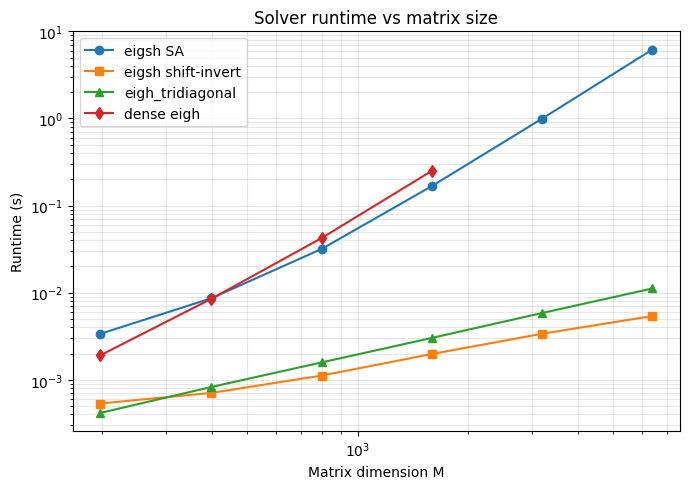

In [10]:
plt.figure(figsize=(7, 5))
M_values = cost["M"].to_numpy()
for column, marker in [("eigsh SA (s)", "o-"), ("eigsh shift-invert (s)", "s-"),
                       ("eigh_tridiagonal (s)", "^-"), ("dense eigh (s)", "d-")]:
    plt.loglog(M_values, cost[column], marker, label=column.replace(" (s)", ""))
plt.xlabel("Matrix dimension M")
plt.ylabel("Runtime (s)")
plt.title("Solver runtime vs matrix size")
plt.grid(True, alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
scaling = pd.DataFrame({
    "Solver": ["eigsh SA", "eigsh shift-invert", "eigh_tridiagonal", "dense eigh"],
    "Fitted exponent p in t ~ M^p": [
        np.polyfit(np.log(M_values), np.log(cost["eigsh SA (s)"]), 1)[0],
        np.polyfit(np.log(M_values), np.log(cost["eigsh shift-invert (s)"]), 1)[0],
        np.polyfit(np.log(M_values), np.log(cost["eigh_tridiagonal (s)"]), 1)[0],
        np.polyfit(np.log(M_values[:4]), np.log(cost["dense eigh (s)"][:4]), 1)[0],
    ],
})
scaling

,Solver,Fitted exponent p in t ~ M^p
0,eigsh SA,2.19992
1,eigsh shift-invert,0.69180
2,eigh_tridiagonal,0.94467
3,dense eigh,2.33466


In [12]:
x_ref, dx_ref, M_ref, H_ref = build_hamiltonian(L, 3200)
energies_sa = np.sort(eigsh(H_ref, k=num_states, which="SA")[0])
energies_si = np.sort(eigsh(H_ref.tocsc(), k=num_states, sigma=0.0, which="LM")[0])
diag_ref = hbar**2 / (mass * dx_ref**2) + 0.5 * mass * omega**2 * x_ref**2
offdiag_ref = -0.5 * (hbar**2 / mass) * np.ones(M_ref - 1) / dx_ref**2
energies_tri = eigh_tridiagonal(diag_ref, offdiag_ref, eigvals_only=True,
                                select="i", select_range=(0, num_states - 1))
print(f"SA vs shift-invert: {np.abs(energies_sa - energies_si).max():.3e}")
print(f"SA vs eigh_tridiagonal: {np.abs(energies_sa - energies_tri).max():.3e}")
assert np.abs(energies_sa - energies_si).max() < 1e-9
assert np.abs(energies_sa - energies_tri).max() < 1e-9
print("All three solvers agree to well within the discretization error.")

SA vs shift-invert: 1.187e-12
SA vs eigh_tridiagonal: 6.039e-12
All three solvers agree to well within the discretization error.


## Results

**Convergence.** With the box fixed at $L = 8$, the fitted slopes of $\log|\Delta E_n|$
against $\log \Delta x$ are 2.00 for every state, and shrinking $\Delta x$ by a factor
of 32 shrinks the error by roughly $32^2 \approx 1000$. This is the expected
second-order behaviour of the centered difference, measured rather than assumed.

**Error model.** The measured errors match
$|\Delta E_n| = \tfrac{\Delta x^2}{32}(2n^2 + 2n + 1)$ to within a fraction of a
percent at the finer grids, with the agreement improving as $\Delta x$ shrinks and the
neglected higher-order terms die away. The error grows quadratically with the state
index, so the highest state requested sets the grid requirement.

**Cost.** The sparse storage stays negligible while a dense copy grows quadratically:
at $M \approx 6400$ the matrix holds about 19 000 nonzeros, roughly 0.26 MB, against
about 328 MB dense. Runtime tells a more interesting story than the memory does.
`eigsh` with `which="SA"` is the slowest option at large $M$, because the low-lying
eigenvalues of this operator are tightly clustered relative to the spectral range and
plain Lanczos converges slowly there. Both `sigma=0.0` shift-invert and the direct
`eigh_tridiagonal` are orders of magnitude faster at the same accuracy, and all three
agree on the eigenvalues. The fitted exponents are empirical over this range of $M$ rather than asymptotic values: at these sizes the fast solvers are partly dominated by call overhead, and the dense routine has not yet reached its eventual $O(M^3)$ regime.

**Consequence for the solver choice.** The sparse-solver argument still holds against
the dense route, but the specific setting matters: for this 1D tridiagonal Hamiltonian
`which="SA"` is the wrong knob, and either shift-invert or the tridiagonal solver
should be preferred at fine grids. This is worth carrying back into the main notebook,
where the current runs use `which="SA"`.